# Phân loại văn bản tiếng Việt — TF-IDF + Naive Bayes

Notebook này xử lý cùng bộ dữ liệu tin tức tiếng Việt như notebook `FastText + BiLSTM`, nhưng dùng cách tiếp cận **học máy cổ điển**:

- **Đặc trưng:** TF-IDF (Term Frequency – Inverse Document Frequency)
- **Mô hình:** Naive Bayes (Multinomial / Complement)


## 0. Cài đặt thư viện

In [ ]:
!pip install underthesea -q

## 1. Import thư viện

In [ ]:
# ==========================
# Standard Libraries
# ==========================
import os
import re
import ast
import gc
import json
import random
import warnings
import pickle

from pathlib import Path
from collections import Counter

# ==========================
# Numerical & Data Processing
# ==========================
import numpy as np
import pandas as pd

# ==========================
# Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Progress Bar
# ==========================
from tqdm.auto import tqdm

# ==========================
# NLP
# ==========================
from underthesea import word_tokenize

# ==========================
# Machine Learning
# ==========================
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")
print("Libraries imported.")

Libraries imported.


In [ ]:
# ══════════════════════════════════════════════
# Reproducibility – fix all random seeds
# ══════════════════════════════════════════════
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
print(f"All seeds fixed to {SEED}")

All seeds fixed to 42


**Download Stopwords**

In [ ]:
!wget -q https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt

## 2. Load Dataset

In [ ]:
DATA_PATH = "/content/merged_file (1).csv"

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)

df_raw.head()

Raw shape: (6474, 7)


,category,date,title,description,text,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


## 3. Chuẩn hoá cột

In [ ]:
def standardize_columns(df_raw: pd.DataFrame):

    lower_map = {c.lower(): c for c in df_raw.columns}

    alias_candidates = {
        "title": ["title"],
        "summary": ["description"],
        "content": ["text"],
        "category": ["category"],
        "author": ["author"],
        "url": ["url"],
        "published_date": ["date"]
    }

    rename_map = {}

    for standard_col, aliases in alias_candidates.items():

        for alias in aliases:

            if alias in lower_map:
                rename_map[lower_map[alias]] = standard_col
                break

    df = df_raw.rename(columns=rename_map).copy()

    required_columns = [
        "title", "summary", "content", "category",
        "author", "url", "published_date"
    ]

    for col in required_columns:
        if col not in df.columns:
            df[col] = np.nan

    return df


df = standardize_columns(df_raw)

print("Current shape:", df.shape)

df.head()

Current shape: (6474, 7)


,category,published_date,title,summary,content,author,url
0,bất động sản,"Chủ nhật, 19/10/2025, 10:09 (GMT+7)",Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm,Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi c...,"Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho b...",Phương Uyên,https://vnexpress.net/gia-dat-can-gio-tang-gap...
1,tâm sự,"Thứ hai, 6/4/2026, 13:00 (GMT+7)","Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...","Những điểm tham quan vẫn đi đầy đủ, chỉ là mọi...","Tôi và bạn trai quen nhau gần hai năm, cả hai ...",Diệu Linh,https://vnexpress.net/tiet-kiem-ban-trai-chuan...
2,sức khỏe,"Thứ tư, 6/5/2026, 09:00 (GMT+7)","Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...","Cùng gia tăng trong mùa nắng nóng, sốc nhiệt x...",Nội dung: Huệ Lan Thiết kế: Thái Hưng Hệ thống...,Vaccine tay chân miệng đã được Bộ Y tế phê duy...,https://vnexpress.net/phan-biet-soc-nhiet-voi-...
3,bất động sản,"Thứ sáu, 29/11/2024, 00:03 (GMT+7)",Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,"TP HCMCăn hộ nổi bật với nội thất màu gỗ ấm, đ...","Căn hộ 3 phòng ngủ, tổng diện tích 100 m2, tọa...",Thu HươngThiết kế: Craftive Design Studio\nẢnh...,https://vnexpress.net/chi-400-trieu-dong-cai-t...
4,bất động sản,"Thứ sáu, 12/12/2025, 00:01 (GMT+7)",6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,"Hồng môn, trúc mây hay lan ý là những loại cây...","Sống trong nhà kín, ít nắng, điều hòa hoạt độn...",Bích Phương,https://vnexpress.net/6-loai-cay-canh-de-trong...


## 4. Làm sạch dữ liệu cơ bản & loại bỏ trùng lặp

In [ ]:
def parse_tags(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if not s or s.lower() == "nan" or s == "[]":
        return []

    if s.startswith("[") and s.endswith("]"):
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return list(dict.fromkeys([str(v).strip() for v in val if str(v).strip()]))
        except Exception:
            pass

    parts = [p.strip() for p in re.split(r",|;|\\|", s) if p.strip()]
    return list(dict.fromkeys(parts))


def clean_basic_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\\s+", " ", x).strip()
    return x


df["title"]    = df["title"].fillna("").astype(str).map(clean_basic_text)
df["summary"]  = df["summary"].fillna("").astype(str).map(clean_basic_text)
df["content"]  = df["content"].fillna("").astype(str).map(clean_basic_text)
df["category"] = df["category"].fillna("").astype(str).str.strip()

before = len(df)

# Drop duplicate URL nếu có URL
if "url" in df.columns and df["url"].notna().any():
    df = df.drop_duplicates(subset=["url"])

# Drop duplicate title + summary
df = df.drop_duplicates(subset=["title", "summary"])

df = df[df["category"] != ""]

# Drop bài không có content/title đủ dùng
full_text = (df["title"] + " " + df["content"]).str.strip()
df = df[full_text.str.len() > 30].copy()

df = df.reset_index(drop=True)

print(f"Before clean: {before:,}")
print(f"After clean:  {len(df):,}")

Before clean: 6,474
After clean:  6,428


## 5. Làm sạch các cột văn bản & gộp văn bản

In [ ]:
text_columns = ["title", "summary", "content"]

for col in text_columns:
    df[col] = df[col].fillna("").astype(str).apply(clean_basic_text)

df["combined_text"] = (
    df["title"] + " " +
    df["summary"] + " " +
    df["content"]
)

df["combined_text"] = df["combined_text"].apply(clean_basic_text)

# Remove short articles
df = df[df["combined_text"].str.len() > 30]
df = df.reset_index(drop=True)

print("Final dataset size:", len(df))

Final dataset size: 6428


## 6. Tiền xử lý tiếng Việt

In [ ]:
with open("vietnamese-stopwords.txt", "r", encoding="utf-8") as f:
    VI_STOPWORDS = set(line.strip() for line in f)

print("Total stopwords:", len(VI_STOPWORDS))

Total stopwords: 1942


### 6.1 Hàm tokenize tiếng Việt

In [ ]:
def vi_tokenize(text):
    return word_tokenize(text, format="text")

### 6.2 Hàm chuẩn hoá văn bản

In [ ]:
def normalize_text(text):
    # Basic cleaning
    text = clean_basic_text(text).lower()
    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)
    # Remove special characters
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ_\\s]", " ", text)
    # Remove extra spaces
    text = re.sub(r"\\s+", " ", text).strip()
    if not text:
        return ""
    # Vietnamese tokenization (word segmentation -> "bất_động_sản")
    text = vi_tokenize(text)
    tokens = []
    for token in text.split():
        token = token.strip()
        if not token:
            continue
        if len(token) < 2 and not token.isdigit():
            continue
        if token in VI_STOPWORDS:
            continue
        tokens.append(token)
    return " ".join(tokens)

### 6.3 Áp dụng tiền xử lý

In [ ]:
tqdm.pandas(desc="Normalizing")
df["clean_text"] = df["combined_text"].progress_apply(normalize_text)
print("Preprocessing completed.")
df[["combined_text", "clean_text"]].head()

Normalizing:   0%|          | 0/6428 [00:00<?, ?it/s]

Preprocessing completed.


,combined_text,clean_text
0,Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm H...,giá đất gấp 2 3 hiệu_ứng khu đô_thị lấn biển k...
1,"Bạn trai chuẩn bị mì tôm, xúc xích khi đi du l...",trai chuẩn_bị mì tôm_xúc xích đi du_lịch chi_p...
2,"Phân biệt sốc nhiệt với bệnh hô hấp, tiêu hóa ...",phân_biệt sốc_nhiệt bệnh hô_hấp tiêu_hóa trẻ g...
3,Chi 400 triệu đồng cải tạo căn hộ wabi sabi ch...,chi 400 triệu đồng cải_tạo căn_hộ wabi sabi vợ...
4,6 loại cây cảnh dễ trồng cho căn hộ thiếu ánh ...,6 cây_cảnh trồng căn_hộ ánh_sáng hồng môn trúc...


## 7. Lọc các nhãn có quá ít mẫu

In [ ]:
MIN_SAMPLES = 10

category_counts = df["category"].value_counts()
valid_categories = category_counts[category_counts >= MIN_SAMPLES].index

df = df[df["category"].isin(valid_categories)].copy()
df.reset_index(drop=True, inplace=True)

print("Remaining classes:", df["category"].nunique())
print("Remaining samples:", len(df))
df["category"].value_counts()

Remaining classes: 14
Remaining samples: 6412


,count
category,
góc nhìn,1776
bất động sản,1330
xe,965
thời sự,556
giáo dục,531
pháp luật,292
khoa học công nghệ,285
sức khỏe,227
thể thao,180


## 8. Mã hoá nhãn (Label Encoding)

In [ ]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

print("Classes:", label_encoder.classes_)
print("\nLabel Mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{i} --> {category}")

Classes: ['bất động sản' 'du lịch' 'giáo dục' 'giải trí' 'góc nhìn'
 'khoa học công nghệ' 'kinh doanh' 'pháp luật' 'sức khỏe' 'thể thao'
 'thời sự' 'tâm sự' 'xe' 'đời sống']

Label Mapping:
0 --> bất động sản
1 --> du lịch
2 --> giáo dục
3 --> giải trí
4 --> góc nhìn
5 --> khoa học công nghệ
6 --> kinh doanh
7 --> pháp luật
8 --> sức khỏe
9 --> thể thao
10 --> thời sự
11 --> tâm sự
12 --> xe
13 --> đời sống


## 9. Khám phá dữ liệu (EDA)

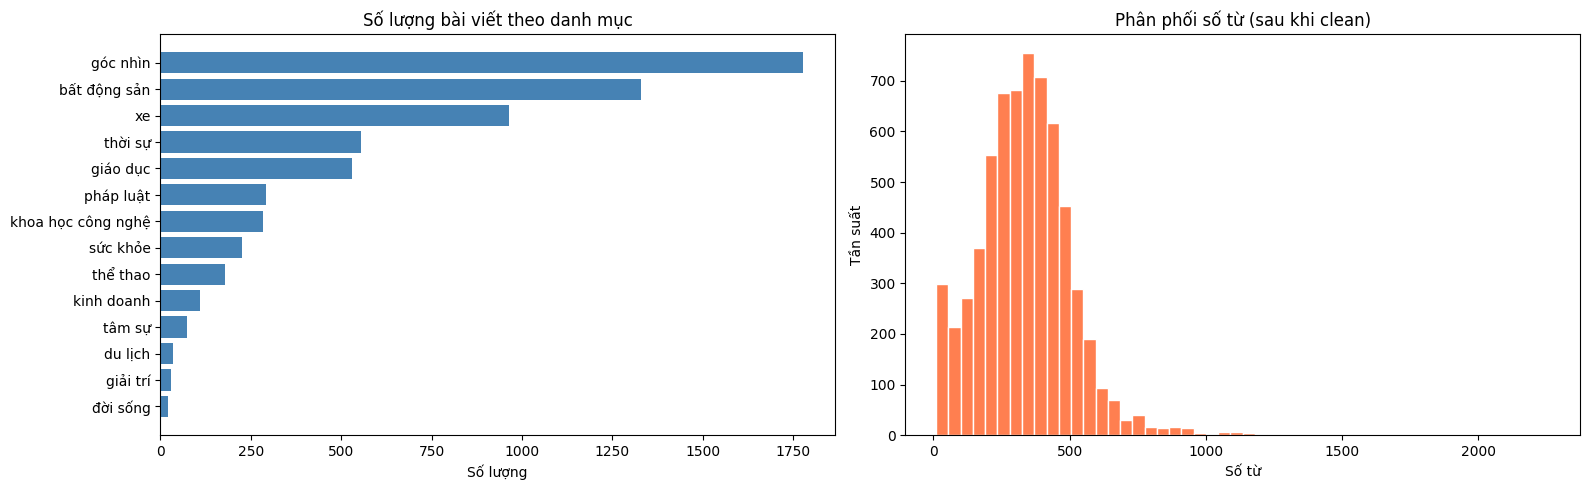


Thống kê độ dài văn bản (số token):
count    6412.000000
mean      337.852932
std       174.796558
min        10.000000
25%       227.000000
50%       334.000000
75%       436.000000
max      2262.000000
Name: clean_text, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[0].set_title("Số lượng bài viết theo danh mục")
axes[0].set_xlabel("Số lượng")

token_len = df["clean_text"].apply(lambda x: len(x.split()))
axes[1].hist(token_len, bins=50, color="coral", edgecolor="white")
axes[1].set_title("Phân phối số từ (sau khi clean)")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

print("\nThống kê độ dài văn bản (số token):")
print(token_len.describe())

## 10. Chia tập Train / Validation / Test

Giữ đúng tỉ lệ 80/10/10 và `random_state=42` như notebook FastText + BiLSTM để so sánh công bằng.

In [ ]:
# Bước 1: tách 80% train, 20% còn lại
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Bước 2: chia tiếp 20% đó thành 10% val + 10% test
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 5129
Validation: 641
Test: 642


## 11. Trích đặc trưng TF-IDF

TF-IDF chuyển mỗi văn bản thành một vector thưa, trọng số mỗi từ = tần suất trong văn bản (TF) nhân với độ hiếm của từ trên toàn corpus (IDF). Từ phổ biến khắp nơi bị giảm trọng số, từ mang tính phân biệt được nâng lên.

Vì văn bản đã được tách từ tiếng Việt (`bất_động_sản`), ta dùng `token_pattern` giữ cả dấu gạch dưới và ký tự tiếng Việt. Ta học từ điển **chỉ trên tập train** để tránh rò rỉ dữ liệu (data leakage).

In [ ]:
VI_TOKEN_PATTERN = r"(?u)\b[0-9a-zA-ZÀ-ỹ_]+\b"

tfidf = TfidfVectorizer(
    token_pattern=VI_TOKEN_PATTERN,
    ngram_range=(1, 2),   # unigram + bigram
    min_df=2,             # bỏ từ xuất hiện < 2 văn bản
    max_df=0.95,          # bỏ từ xuất hiện trong > 95% văn bản
    sublinear_tf=True,    # 1 + log(tf), giảm ảnh hưởng từ lặp nhiều
    max_features=50000
)

# Fit CHỈ trên train, transform cho cả 3 tập
X_train = tfidf.fit_transform(X_train_text)
X_val   = tfidf.transform(X_val_text)
X_test  = tfidf.transform(X_test_text)

print("TF-IDF train matrix:", X_train.shape)
print("TF-IDF val matrix:  ", X_val.shape)
print("TF-IDF test matrix: ", X_test.shape)
print("Vocabulary size:    ", len(tfidf.vocabulary_))

TF-IDF train matrix: (5129, 50000)
TF-IDF val matrix:   (641, 50000)
TF-IDF test matrix:  (642, 50000)
Vocabulary size:     50000


## 12. Hàm tiện ích — huấn luyện & đánh giá

In [ ]:
def evaluate(model, X, y_true, name=""):
    """Dự đoán và trả về dict các chỉ số đánh giá."""
    y_pred = model.predict(X)
    return {
        "name"            : name,
        "pred"            : y_pred,
        "accuracy"        : accuracy_score(y_true, y_pred),
        "macro_f1"        : f1_score(y_true, y_pred, average="macro"),
        "macro_precision" : precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall"    : recall_score(y_true, y_pred, average="macro"),
        "weighted_f1"     : f1_score(y_true, y_pred, average="weighted"),
    }


def run_experiment(name, model, X_tr, y_tr, X_ev, y_ev):
    """Fit model rồi đánh giá trên tập đánh giá (val hoặc test)."""
    model.fit(X_tr, y_tr)
    res = evaluate(model, X_ev, y_ev, name=name)
    res["model"] = model
    print(f"=== {name} ===")
    print(f"Accuracy    : {res['accuracy']:.4f}")
    print(f"Macro F1    : {res['macro_f1']:.4f}")
    print(f"Weighted F1 : {res['weighted_f1']:.4f}")
    print()
    return res

## 13. Thí nghiệm A — MultinomialNB (Baseline)

Multinomial Naive Bayes là lựa chọn kinh điển cho phân loại văn bản với đặc trưng đếm/TF-IDF. Đánh giá trên tập **validation** trước.

In [ ]:
result_A = run_experiment(
    "A – MultinomialNB (baseline)",
    MultinomialNB(alpha=1.0),
    X_train, y_train,
    X_val, y_val
)

=== A – MultinomialNB (baseline) ===
Accuracy    : 0.7129
Macro F1    : 0.3582
Weighted F1 : 0.6544



## 14. Thí nghiệm B — ComplementNB (xử lý mất cân bằng)

ComplementNB là biến thể của Naive Bayes được thiết kế riêng cho **dữ liệu mất cân bằng nhãn**: thay vì ước lượng tham số từ các mẫu thuộc một lớp, nó dùng phần bù (complement) của lớp đó, giúp ổn định hơn khi số mẫu giữa các lớp chênh lệch.

In [ ]:
result_B = run_experiment(
    "B – ComplementNB",
    ComplementNB(alpha=1.0),
    X_train, y_train,
    X_val, y_val
)

=== B – ComplementNB ===
Accuracy    : 0.8362
Macro F1    : 0.5307
Weighted F1 : 0.8077



## 15. Thí nghiệm C — Tinh chỉnh siêu tham số (GridSearch)

Tìm `alpha` (hệ số Laplace smoothing) và loại NB tốt nhất bằng cross-validation trên tập train, tối ưu theo **Macro F1** (phù hợp với dữ liệu mất cân bằng).

In [ ]:
param_grid = [
    {"clf": [MultinomialNB()], "clf__alpha": [0.05, 0.1, 0.3, 0.5, 1.0]},
    {"clf": [ComplementNB()],  "clf__alpha": [0.05, 0.1, 0.3, 0.5, 1.0]},
]

pipe = Pipeline([("clf", MultinomialNB())])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV Macro F1:", round(grid.best_score_, 4))

best_nb = grid.best_estimator_
result_C = evaluate(best_nb, X_val, y_val, name="C – GridSearch (best NB)")
result_C["model"] = best_nb
print(f"\n[Validation] Accuracy: {result_C['accuracy']:.4f} | Macro F1: {result_C['macro_f1']:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'clf': MultinomialNB(), 'clf__alpha': 0.05}
Best CV Macro F1: 0.6218

[Validation] Accuracy: 0.8877 | Macro F1: 0.6375


## 16. Bảng so sánh 3 thí nghiệm (trên Validation)

In [ ]:
results_list = [result_A, result_B, result_C]

df_compare = pd.DataFrame([
    {
        "Thí nghiệm"   : r["name"],
        "Accuracy"     : round(r["accuracy"],        4),
        "Macro F1"     : round(r["macro_f1"],        4),
        "Macro Prec."  : round(r["macro_precision"], 4),
        "Macro Recall" : round(r["macro_recall"],    4),
        "Weighted F1"  : round(r["weighted_f1"],     4),
    }
    for r in results_list
])

df_compare = df_compare.sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_compare

,Thí nghiệm,Accuracy,Macro F1,Macro Prec.,Macro Recall,Weighted F1
0,C – GridSearch (best NB),0.8877,0.6375,0.7285,0.6155,0.8753
1,B – ComplementNB,0.8362,0.5307,0.5875,0.5118,0.8077
2,A – MultinomialNB (baseline),0.7129,0.3582,0.4499,0.3413,0.6544


## 17. Đánh giá mô hình tốt nhất trên tập TEST

In [ ]:
best_val = max(results_list, key=lambda r: r["macro_f1"])
best_model = best_val["model"]
print("Mô hình tốt nhất (theo Macro F1 trên val):", best_val["name"])

# Đánh giá cuối cùng trên tập test (chưa từng dùng)
test_res = evaluate(best_model, X_test, y_test, name=best_val["name"])

print("\n===== KẾT QUẢ TRÊN TẬP TEST =====")
print(f"Accuracy    : {test_res['accuracy']:.4f}")
print(f"Macro F1    : {test_res['macro_f1']:.4f}")
print(f"Weighted F1 : {test_res['weighted_f1']:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test, test_res["pred"],
    target_names=label_encoder.classes_,
    zero_division=0
))

Mô hình tốt nhất (theo Macro F1 trên val): C – GridSearch (best NB)

===== KẾT QUẢ TRÊN TẬP TEST =====
Accuracy    : 0.8801
Macro F1    : 0.5993
Weighted F1 : 0.8642

Classification Report:

                    precision    recall  f1-score   support

      bất động sản       0.89      0.98      0.93       133
           du lịch       0.00      0.00      0.00         3
          giáo dục       1.00      0.72      0.84        53
          giải trí       0.00      0.00      0.00         3
          góc nhìn       0.82      0.96      0.88       178
khoa học công nghệ       0.96      0.79      0.86        28
        kinh doanh       1.00      0.18      0.31        11
         pháp luật       0.83      0.83      0.83        30
          sức khỏe       1.00      1.00      1.00        23
          thể thao       1.00      1.00      1.00        18
           thời sự       0.81      0.77      0.79        56
            tâm sự       0.00      0.00      0.00         7
                xe       0.9

## 18. Confusion Matrix & F1 theo từng lớp

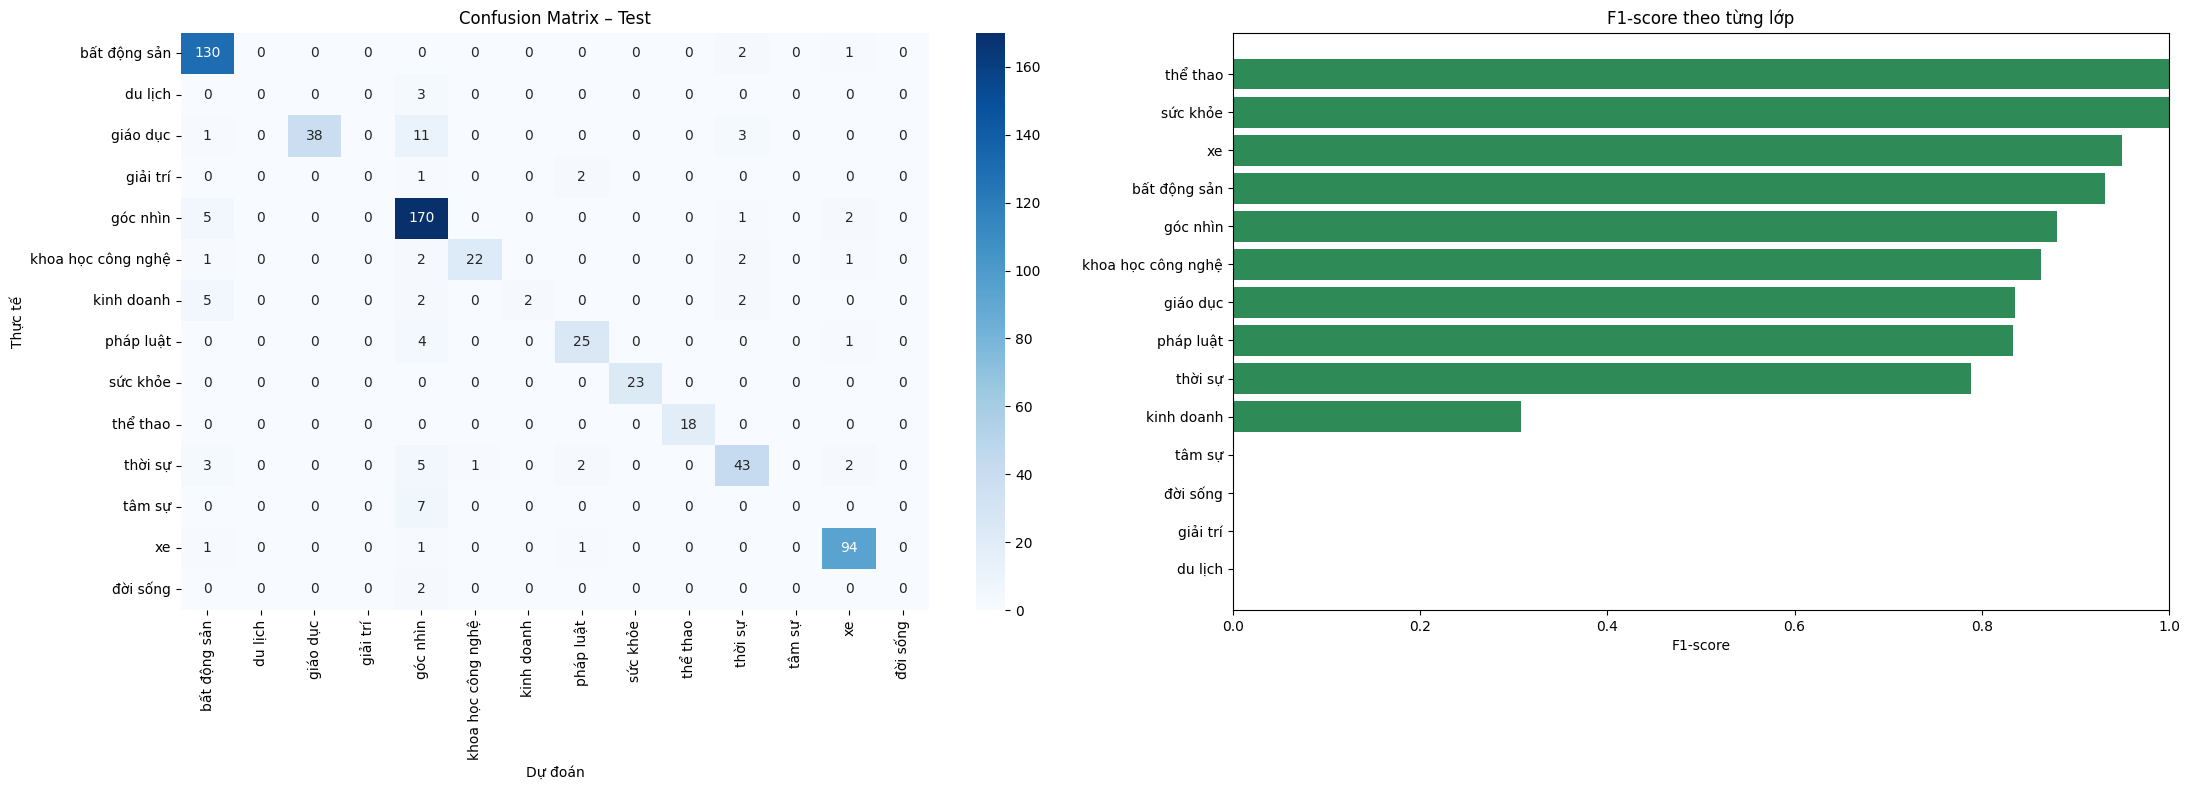

In [ ]:
y_pred_test = test_res["pred"]

cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix – Test")
axes[0].set_xlabel("Dự đoán")
axes[0].set_ylabel("Thực tế")

per_class_f1 = f1_score(y_test, y_pred_test, average=None)
order = np.argsort(per_class_f1)
axes[1].barh(
    np.array(label_encoder.classes_)[order],
    per_class_f1[order],
    color="seagreen"
)
axes[1].set_title("F1-score theo từng lớp")
axes[1].set_xlabel("F1-score")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 19. Từ khoá đặc trưng nhất của mỗi danh mục

Với Naive Bayes ta có thể xem những token có log-probability cao nhất cho mỗi lớp — giúp giải thích mô hình đã học gì.

In [ ]:
import numpy as np

# Lấy MultinomialNB/ComplementNB cuối cùng từ pipeline hoặc model trực tiếp
nb_for_inspect = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model

feature_names = np.array(tfidf.get_feature_names_out())
log_prob = nb_for_inspect.feature_log_prob_

TOP_N = 12
for i, cat in enumerate(label_encoder.classes_):
    top_idx = np.argsort(log_prob[i])[::-1][:TOP_N]
    keywords = ", ".join(feature_names[top_idx])
    print(f"[{cat}]\n  {keywords}\n")

[bất động sản]
  dự_án, khu, đất, m2, đầu_tư, căn_hộ, không_gian, bất_động_sản, diện_tích, khu_vực, tầng, đồng

[du lịch]
  du_khách, du_lịch, 30 4, sông, tham_quan, dịp, quán, khu_vực, lượt, cầu, trải_nghiệm, 4

[giáo dục]
  trường, đại_học, thi, thí_sinh, thpt, tốt_nghiệp, xét, thi tốt_nghiệp, tuyển, trường đại_học, tốt_nghiệp thpt, chuẩn

[giải trí]
  diễn_viên, phim, tác_phẩm, video, người_mẫu, đạo_diễn, thời_trang, khán_giả, điện_ảnh, trang_phục, nhân_vật, vai

[góc nhìn]
  việt_nam, đi, có_thể, chúng_ta, ta, xã_hội, hàng, học, hai, tiền, không_thể, vấn_đề

[khoa học công nghệ]
  công_nghệ, thiết_bị, công_ty, apple, ứng_dụng, dữ_liệu, có_thể, sử_dụng, iphone, phát_triển, sản_phẩm, ảnh

[kinh doanh]
  mua, tỷ, đồng, tỷ đồng, mua đất, đất, ngân_hàng, đầu_tư, vay, giá, tiền, triệu

[pháp luật]
  công_an, điều_tra, cảnh_sát, hành_vi, án, vụ, bị_cáo, nạn_nhân, tội, vụ án, 4, cơ_quan

[sức khỏe]
  vaccine, tiêm, bệnh, bác_sĩ, viêm, virus, mắc, mũi, tiêm_chủng, vnvc, điều_trị, tiêm vacci

## 20. Lưu mô hình & artifacts

In [ ]:
# Lưu vectorizer, model, label encoder để dùng lại khi inference
with open("tfidf_vectorizer.pkl", "wb") as fh:
    pickle.dump(tfidf, fh)

with open("naive_bayes_classifier.pkl", "wb") as fh:
    pickle.dump(best_model, fh)

with open("label_encoder.pkl", "wb") as fh:
    pickle.dump(label_encoder, fh)

meta = {
    "best_experiment": best_val["name"],
    "test_accuracy"  : float(test_res["accuracy"]),
    "test_macro_f1"  : float(test_res["macro_f1"]),
    "n_classes"      : int(len(label_encoder.classes_)),
    "tfidf_features" : int(len(tfidf.vocabulary_)),
}
with open("nb_meta.json", "w", encoding="utf-8") as fh:
    json.dump(meta, fh, ensure_ascii=False, indent=2)

print("Saved: tfidf_vectorizer.pkl, naive_bayes_classifier.pkl, label_encoder.pkl, nb_meta.json")
print(meta)

Saved: tfidf_vectorizer.pkl, naive_bayes_classifier.pkl, label_encoder.pkl, nb_meta.json
{'best_experiment': 'C – GridSearch (best NB)', 'test_accuracy': 0.8800623052959502, 'test_macro_f1': 0.5992964290381299, 'n_classes': 14, 'tfidf_features': 50000}


## 21. Hàm dự đoán cho bài viết mới (Inference)

In [ ]:
def predict_category(text: str, top_k: int = 3) -> list:
    """
    Dự đoán danh mục cho một bài viết tiếng Việt.

    Parameters
    ----------
    text  : str  – văn bản gốc (chưa qua tiền xử lý)
    top_k : int  – số danh mục trả về (theo xác suất giảm dần)

    Returns
    -------
    list of (category, probability) tuples
    """
    cleaned = normalize_text(text)
    X = tfidf.transform([cleaned])
    proba = best_model.predict_proba(X)[0]
    top_idx = np.argsort(proba)[::-1][:top_k]
    return [(label_encoder.classes_[i], float(proba[i])) for i in top_idx]


# Ví dụ
sample = "Đội tuyển Việt Nam giành chiến thắng quan trọng trong trận đấu vòng loại World Cup tối qua."
for cat, p in predict_category(sample):
    print(f"{cat:25s} {p:.4f}")

thể thao                  0.9812
góc nhìn                  0.0148
giáo dục                  0.0021
